# GEOGLOWS river_id seeding

Assigns each USGS gage its nearest GEOGLOWS v2 reach (`LINKNO` = `river_id`)
by snapping gage points to the GEOGLOWS hydrofabric stream lines.
Complements the NWM half of the seed, which comes from Iman's COMID list
already merged into `merged_gages.geojson`.

**Method** (plan §6): reproject to EPSG:5070 (meters), nearest stream line
within a buffer, keep the snap distance as a crude confidence score, skip
the smallest headwater reaches. Expect ~70% correct — the web app exists
to fix the rest.

**Inputs:** `merged_gages.geojson` + GEOGLOWS v2 hydrofabric (public S3, no credentials).
**Outputs:** `merged_gages_geoglows.geojson` and `seed.csv` (the Week 7 DB seed).

In [1]:
import json
import urllib.request
from pathlib import Path

import geopandas as gpd
import pyogrio
import pandas as pd

# ---- Config -----------------------------------------------------------
GAGES_PATH = "../tethysapp/hydro_correlation_tool/public/data/merged_gages.geojson"
BUCKET = "https://geoglows-v2.s3.amazonaws.com"
VPU_BOUNDS_URL = f"/vsicurl/{BUCKET}/hydrography-global/vpu-boundaries.gpkg"
HYDRO_DIR = Path("geoglows_hydrography")   # downloaded streams gpkgs land here (gitignored)
HYDRO_DIR.mkdir(exist_ok=True)

CRS_METERS = "EPSG:5070"   # Albers CONUS — buffer/snap distances in real meters
MAX_SNAP_M = 500           # no reach within this distance -> no match (tune empirically)
MIN_STREAM_ORDER = 2       # skip order-1 headwaters so gages don't snap to tiny tributaries

In [2]:
# ---- Load gages -------------------------------------------------------
gages = gpd.read_file(GAGES_PATH)
print(len(gages), "gages |", gages.crs)
gages.head(3)

9113 gages | EPSG:4326


,USGSID,station_nm,COMID,geometry
0,USGS-02339495,OSELIGEE CREEK NEAR LANETT AL,3296804,POINT (-85.19633 32.90152)
1,USGS-02342500,"UCHEE CREEK NEAR FORT MITCHELL, AL.",3435970,POINT (-85.01493 32.31681)
2,USGS-02342937,"SOUTH FORK COWIKEE CREEK NR HOWE, AL",3437910,POINT (-85.2138 32.01679)


## 1. Which VPUs cover CONUS?

The hydrofabric is split into 125 VPU (Vector Processing Unit) regions.
`/vsicurl/` + a bbox reads only the CONUS window of the 1.9 GB boundaries
file over HTTP instead of downloading it.

In [ ]:
conus_bbox = tuple(gages.total_bounds)  # (minx, miny, maxx, maxy) in 4326
vpus = gpd.read_file(VPU_BOUNDS_URL, bbox=conus_bbox)
print(vpus.columns.tolist())
vpus.head(10)

['VPU', 'geometry']


,VPU,geometry
0,704,"MULTIPOLYGON (((-127.62633 50.15458, -127.6263..."
1,702,"MULTIPOLYGON (((-123.86494 39.92939, -123.8649..."
2,703,"MULTIPOLYGON (((-120.26028 34.55539, -120.2603..."
3,706,"MULTIPOLYGON (((-115.8056 51.07536, -115.8056 ..."
4,701,"MULTIPOLYGON (((-115.17794 29.51239, -115.1781..."
5,714,"MULTIPOLYGON (((-112.96792 44.42627, -112.9679..."
6,715,"MULTIPOLYGON (((-108.42306 30.1935, -108.42383..."
7,707,"MULTIPOLYGON (((-100.78432 57.43871, -100.7844..."
8,709,"MULTIPOLYGON (((-92.28131 46.3369, -92.28131 4..."
9,713,"MULTIPOLYGON (((-89.26061 30.79794, -89.26106 ..."


In [ ]:
print(vpus['VPU'])

In [5]:
# Auto-detect the VPU-code column (name not documented; inspect the print above
# and hard-code it here if this guess picks the wrong one).
vpu_col = next(c for c in vpus.columns if "vpu" in c.lower())
print("Using VPU column:", vpu_col)
vpus[vpu_col] = pd.to_numeric(vpus[vpu_col]).astype("Int64")  # codes ship as strings

# A gage belongs to the VPU polygon that contains it.
gage_vpu = gpd.sjoin(gages, vpus[[vpu_col, "geometry"]].to_crs(gages.crs),
                     how="left", predicate="within")

# Coastal/border gages can fall just outside every polygon -> nearest VPU
missing = gage_vpu[vpu_col].isna()
if missing.any():
    near = gpd.sjoin_nearest(gages.loc[missing.values, ["USGSID", "geometry"]].to_crs(CRS_METERS),
                             vpus[[vpu_col, "geometry"]].to_crs(CRS_METERS), how="left")
    gage_vpu.loc[missing, vpu_col] = near[vpu_col].values
    print(f"assigned {missing.sum()} stray gages to nearest VPU")

conus_vpus = sorted(gage_vpu[vpu_col].dropna().unique())
print("CONUS VPUs:", conus_vpus)
print("Gages per VPU:")
print(gage_vpu[vpu_col].value_counts(dropna=False))

Using VPU column: VPU
assigned 93 stray gages to nearest VPU
CONUS VPUs: [np.int64(701), np.int64(702), np.int64(703), np.int64(704), np.int64(706), np.int64(708), np.int64(709), np.int64(712), np.int64(713), np.int64(714), np.int64(715)]
Gages per VPU:
VPU
714    3060
712    1319
713    1219
703     868
704     792
715     689
709     597
702     438
706     114
708      14
701       3
Name: count, dtype: Int64


## 2. Download the streams file for each CONUS VPU

~270 MB per VPU; skips files already downloaded, so re-running is cheap.

In [6]:
def streams_path(vpu):
    return HYDRO_DIR / f"streams_{vpu}.gpkg"

for vpu in conus_vpus:
    dest = streams_path(vpu)
    if dest.exists():
        print(f"vpu={vpu}: already downloaded")
        continue
    url = f"{BUCKET}/hydrography/vpu={vpu}/streams_{vpu}.gpkg"
    print(f"vpu={vpu}: downloading {url} ...")
    urllib.request.urlretrieve(url, dest)
    print(f"  -> {dest} ({dest.stat().st_size / 1e6:.0f} MB)")

vpu=701: already downloaded
vpu=702: already downloaded
vpu=703: already downloaded
vpu=704: already downloaded
vpu=706: already downloaded
vpu=708: already downloaded
vpu=709: already downloaded
vpu=712: already downloaded
vpu=713: already downloaded
vpu=714: already downloaded
vpu=715: already downloaded


## 3. Snap gages to their nearest reach, one VPU at a time

`sjoin_nearest` uses a spatial index under the hood; `distance_col` records
how far each gage had to snap — small = trustworthy, large = review first.

In [7]:
matches = []
id_col = order_col = None

for vpu in conus_vpus:
    sub = gage_vpu[gage_vpu[vpu_col] == vpu][["USGSID", "geometry"]]
    if sub.empty:
        continue

    # bbox-filtered read keeps memory sane. NOTE: the bbox must be in the
    # FILE's CRS — the hydrofabric ships in EPSG:3857 (meters), not 4326,
    # so transform the gage bounds first or the filter selects nothing.
    file_crs = pyogrio.read_info(streams_path(vpu))["crs"]
    minx, miny, maxx, maxy = sub.to_crs(file_crs).total_bounds
    margin = 5000  # meters, ~5 km
    streams = gpd.read_file(streams_path(vpu),
                            bbox=(minx - margin, miny - margin, maxx + margin, maxy + margin))

    if id_col is None:  # detect field names once, from real data
        print("Stream columns:", streams.columns.tolist())
        id_col = next(c for c in streams.columns if c.lower() == "linkno")
        order_col = next((c for c in streams.columns if "order" in c.lower()), None)
        print(f"Using id column: {id_col!r}, stream-order column: {order_col!r}")

    if order_col is not None:
        streams = streams[streams[order_col] >= MIN_STREAM_ORDER]

    m = gpd.sjoin_nearest(
        sub.to_crs(CRS_METERS),
        streams[[id_col, "geometry"]].to_crs(CRS_METERS),
        how="left", max_distance=MAX_SNAP_M, distance_col="geoglows_snap_m",
    )
    matched = m[id_col].notna().sum()
    print(f"vpu={vpu}: {matched}/{len(sub)} gages matched")
    matches.append(m[["USGSID", id_col, "geoglows_snap_m"]])

Stream columns: ['LINKNO', 'DSLINKNO', 'strmOrder', 'USContArea', 'DSContArea', 'TDXHydroRegion', 'VPUCode', 'TopologicalOrder', 'LengthGeodesicMeters', 'TerminalLink', 'musk_k', 'musk_x', 'geometry']
Using id column: 'LINKNO', stream-order column: 'strmOrder'
vpu=701: 3/3 gages matched
vpu=702: 404/438 gages matched
vpu=703: 819/868 gages matched
vpu=704: 763/792 gages matched
vpu=706: 108/114 gages matched
vpu=708: 11/14 gages matched
vpu=709: 553/597 gages matched
vpu=712: 1214/1319 gages matched
vpu=713: 1060/1219 gages matched
vpu=714: 2925/3060 gages matched
vpu=715: 656/689 gages matched


In [8]:
# Combine; a gage can appear twice if two reaches tie for nearest -> keep the closest
result = (pd.concat(matches, ignore_index=True)
            .sort_values("geoglows_snap_m")
            .drop_duplicates("USGSID", keep="first")
            .rename(columns={id_col: "geoglows_river_id"}))
result["geoglows_river_id"] = result["geoglows_river_id"].astype("Int64")

seed = gages.merge(result, on="USGSID", how="left")
print(f"{seed['geoglows_river_id'].notna().sum()}/{len(seed)} gages got a geoglows_river_id")

8491/9113 gages got a geoglows_river_id


## 4. QA — how far did gages have to snap?

Big distances are the matches to distrust (and exactly what the app's
verify workflow is for).

count    8.491000e+03
mean     4.084977e+01
std      6.570160e+01
min      8.027650e-09
25%      8.219496e+00
50%      1.957313e+01
75%      4.281652e+01
max      4.999288e+02
Name: geoglows_snap_m, dtype: float64


<Axes: title={'center': 'Snap distance (m)'}, ylabel='Frequency'>

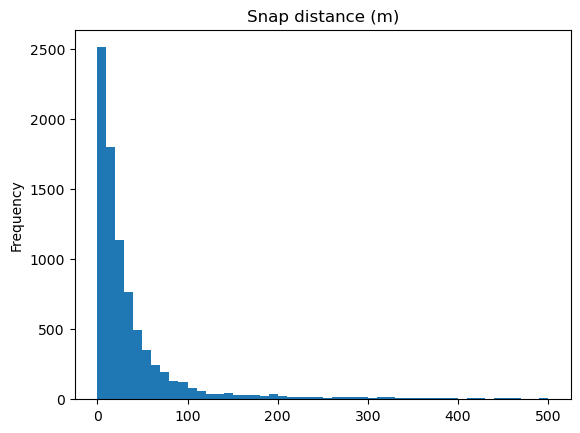

In [9]:
print(seed["geoglows_snap_m"].describe())
seed["geoglows_snap_m"].plot.hist(bins=50, title="Snap distance (m)")

In [10]:
# The 20 most-suspicious matches — worth eyeballing in the app later
seed.nlargest(20, "geoglows_snap_m")[["USGSID", "station_nm", "geoglows_river_id", "geoglows_snap_m"]]

,USGSID,station_nm,geoglows_river_id,geoglows_snap_m
8051,USGS-09309600,"FAIRVIEW TUNNEL NEAR FAIRVIEW, UT",710777964,499.928848
4387,USGS-07010070,"Sebago Creek near Rock Hill, MO",760446871,499.816280
5835,USGS-02146470,"LITTLE HOPE CR AT SENECA PLACE AT CHARLOTTE, NC",750029309,497.406224
1458,USGS-01482100,DELAWARE RIVER AT DEL MEM BRIDGE AT WILMINGTON DE,750097270,495.734362
4124,USGS-02441300,"CATALPA CREEK AT MAYHEW, MS",750213469,495.267046
4207,USGS-07285400,"BATUPAN BOGUE AT GRENADA, MS",760309130,490.476355
1717,USGS-02303205,BAKER CREEK AT MCINTOSH ROAD NEAR ANTIOCH FL,750052000,490.086858
3437,USGS-08010000,"Bayou Des Cannes near Eunice, LA",760123012,489.603456
524,USGS-09527630,"BROCK RESERVOIR INLET NEAR CALEXICO, CA",710425167,488.826735
7465,USGS-07346045,"Black Cypress Bayou at Jefferson, TX",760164437,488.238546


## 5. Save the seed

`seed.csv` is the Week 7 database-initializer input (plan §5.3 column names,
`verification_status = Unverified` for every row).

In [11]:
seed.to_file("merged_gages_geoglows.geojson", driver="GeoJSON")

csv_out = pd.DataFrame({
    "usgs_id": seed["USGSID"],
    "gage_name": seed["station_nm"],
    "latitude": seed.geometry.y,
    "longitude": seed.geometry.x,
    "nwm_feature_id": seed["COMID"],
    "geoglows_river_id": seed["geoglows_river_id"],
    "verification_status": "Unverified",
})
csv_out.to_csv("seed.csv", index=False)
print("Wrote merged_gages_geoglows.geojson and seed.csv")
csv_out.head()

Wrote merged_gages_geoglows.geojson and seed.csv


,usgs_id,gage_name,latitude,longitude,nwm_feature_id,geoglows_river_id,verification_status
0,USGS-02339495,OSELIGEE CREEK NEAR LANETT AL,32.901516,-85.196331,3296804,750182109,Unverified
1,USGS-02342500,"UCHEE CREEK NEAR FORT MITCHELL, AL.",32.316815,-85.014931,3435970,750241324,Unverified
2,USGS-02342937,"SOUTH FORK COWIKEE CREEK NR HOWE, AL",32.016786,-85.213800,3437910,750214100,Unverified
3,USGS-023432415,CHATTAHOOCHEE R .36 MI DS WFG DAM NR FT GAINES...,31.622194,-85.059167,None,750229503,Unverified
4,USGS-02361000,"CHOCTAWHATCHEE RIVER NEAR NEWTON, AL.",31.342949,-85.610491,2188031,750237798,Unverified
